# Lab 19: Tree-Based Models — Random Forests
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 30 min Core + 15 min Extension + SHAP Deep Dive

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

---

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## Part 1: Find the Bug — Model Comparison (10 min)

The following code trains three models and reports their performance.
**Something is wrong with how the comparison is set up.** Find it, fix it, explain.

In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_train, rf.predict(X_train)):.4f}")  # \u2190 WRONG: using training set
print()
print('Conclusion: Random Forest achieves R\u00b2 > 0.97! Far superior to alternatives.')

=== Model Comparison ===
Single Tree  — R²: 0.6187
Ridge        — R²: 0.5759
Random Forest — R²: 0.9735

Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.


### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific line and error type)
2. **Why is this dangerous?** (what misleading conclusion does it lead to?)
3. **Fix the code below** and report the correct R²

**Verification checkpoint:** After fixing, the RF Test R² should be between 0.78 and 0.83. If you get >0.95, you haven't found the bug.

4. **Which chapter concept does this error violate?** (hint: Ch 15)

Q1 Ans: Instead of using train values, the correct input should be y_test and X_test within the Random Forest

Q2 Ans: The reason is connecitng to the performance of the Random Forest model. To be specific, Random Forest model tend to run better performance in training instead of actual testing. 

In [4]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Fix the model comparison bug from Part 1
# -----------------------------------------------------------

# YOUR FIX HERE
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_test, rf.predict(X_test)):.4f}")  # \u2190 WRONG: using training set
print()
print('Conclusion: Random Forest achieves R\u00b2 > 0.80!')

=== Model Comparison ===
Single Tree  — R²: 0.6187
Ridge        — R²: 0.5759
Random Forest — R²: 0.8049

Conclusion: Random Forest achieves R² > 0.80!


Q4 Ans: The bias-variance tradeoff within Chapter 15

## Part 2: Find the Methodological Flaw — Feature Importance (10 min)

The following analysis uses feature importance to make a **causal claim**.
The code runs correctly. The methodology is wrong. Find the flaw.

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Feature importance with flawed causal reasoning
# -----------------------------------------------------------

rf_correct = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_correct.fit(X_train, y_train)

importance = pd.Series(rf_correct.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importance (MDI):')
print(importance.round(4))
print()
print('POLICY RECOMMENDATION:')
print(f'The top predictor is {importance.index[0]} (importance = {importance.iloc[0]:.3f}).')
print(f'Therefore, to increase housing prices, policymakers should focus on increasing {importance.index[0]}.')
print(f'The second most important lever is {importance.index[1]}.')

Feature Importance (MDI):
MedInc        0.5259
AveOccup      0.1381
Latitude      0.0886
Longitude     0.0883
HouseAge      0.0543
AveRooms      0.0444
Population    0.0306
AveBedrms     0.0297
dtype: float64

POLICY RECOMMENDATION:
The top predictor is MedInc (importance = 0.526).
Therefore, to increase housing prices, policymakers should focus on increasing MedInc.
The second most important lever is AveOccup.


Text(0.5, 1.0, 'MDI Importance Graph')

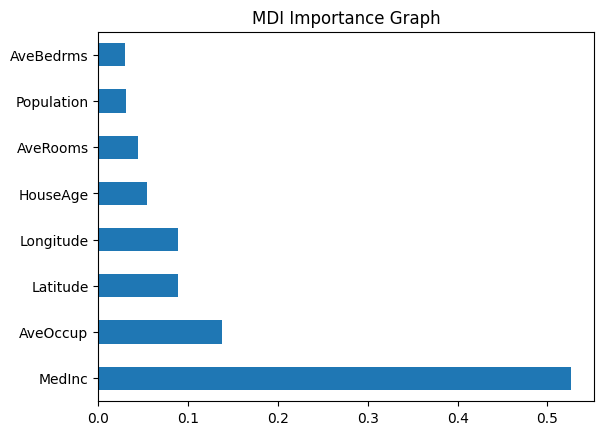

In [6]:
importance.plot(kind="barh")
plt.title("MDI Importance Graph")

### YOUR DIAGNOSIS

1. **What is the methodological flaw?** (the code is correct — the reasoning is wrong)
2. **Why can't we use MDI for policy recommendations?** (connect to Ch 10 DAGs and Ch 15 prediction vs. explanation)
3. **What would you need to make a causal claim?** (hint: Ch 24 DML)
4. **Bonus:** MDI has a known statistical bias. What is it, and what alternative would you use?

**Verification checkpoint:** Your diagnosis should mention at least: (a) prediction ≠ causation, (b) confounding/omitted variables, (c) MDI bias toward high-cardinality features.

Q1 Ans: The answer is related to the characteristic of feature importance. To be specific, it served the purpose of prediction, which telling whether characteristic contributed the most to the prediction instead of using it as the explanation of the result, in other words causation.

Q2 Ans: The reason is due to the DAGs property. To be specific, the confounding or omitted variables between multiple characteristics. The second reason would be the enhance of predictive accuracy instead of the mechanism of causality within Ch 15. In other words, it did not indicate that there would be effect for the variable that intervened.

Q3 Ans: To make a causal claim, the double machine learning should be used for the causality interpretation method. To be specific, estimate treatment effect by excluding confounders or ensuring the randomized.

Q4 Ans: The statistical bias indicated the favor towards high-cardinality and variables that are continuous. It would score higher importance due to the higher unnecessary split with lack of help. The alternative might be the use of permutation importance, since the raondom disturb of the characteristic of the values would less rely on the impurity and be less affected by the cardinality features.


In [7]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Run permutation importance and write a proper (non-causal)
# interpretation of the results
# -----------------------------------------------------------

# YOUR CORRECTED ANALYSIS HERE

permutation_calc = permutation_importance(rf_correct, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)

importance_permutation = pd.Series(permutation_calc.importances_mean, index=X.columns).sort_values(ascending=False)

print("The test set of Permutation Importance: ")
print(importance_permutation.round(4))
print()

The test set of Permutation Importance: 
MedInc        0.7387
Latitude      0.4438
Longitude     0.3368
AveOccup      0.2036
HouseAge      0.0725
AveRooms      0.0265
AveBedrms     0.0097
Population    0.0084
dtype: float64



## Part 3: Hyperparameter Tuning + XGBoost Comparison (10 min)

Tune the RF, then compare against XGBoost (gradient boosting).

In [8]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune RF with GridSearchCV and compare with GBR
# -----------------------------------------------------------

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5],
}

# 1. GridSearchCV on RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

search_grid = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE),param_grid, cv=5, scoring='r2',n_jobs=-1)

search_grid.fit(X_train, y_train)

the_best_rf = search_grid.best_estimator_

print("Best:", the_best_rf)

# 2. Fit GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
the_fit_GBRegressor = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE)
the_fit_GBRegressor.fit(X_train, y_train)

# 3. Compare Test RMSE and R\u00b2 for: Ridge, RF (default), RF (tuned), GBR
models = {
    'Ridge': ridge,
    'Default_RF': rf_correct,
    'Tuned_RF': the_best_rf,
    'GBR': the_fit_GBRegressor
}

for name, model in models.items():
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(name, "r2:", round(r2, 4), "rmse:", round(rmse,4))
# 4. Which model wins? By how much? Is the difference practically significant?


Best: RandomForestRegressor(max_features='sqrt', n_estimators=500, random_state=42)
Ridge r2: 0.5759 rmse: 0.7455
Default_RF r2: 0.8062 rmse: 0.5039
Tuned_RF r2: 0.8147 rmse: 0.4928
GBR r2: 0.8288 rmse: 0.4736


Q4 Ans: GBR won, it is higher by 0.0141 than tuned_rf. It is not highly practically significant. In other words, the difference is small.

---

## Extension: SHAP Analysis (5200 depth — 15 min)

Use SHAP to explain individual predictions. Compare MDI ranking vs. SHAP ranking.

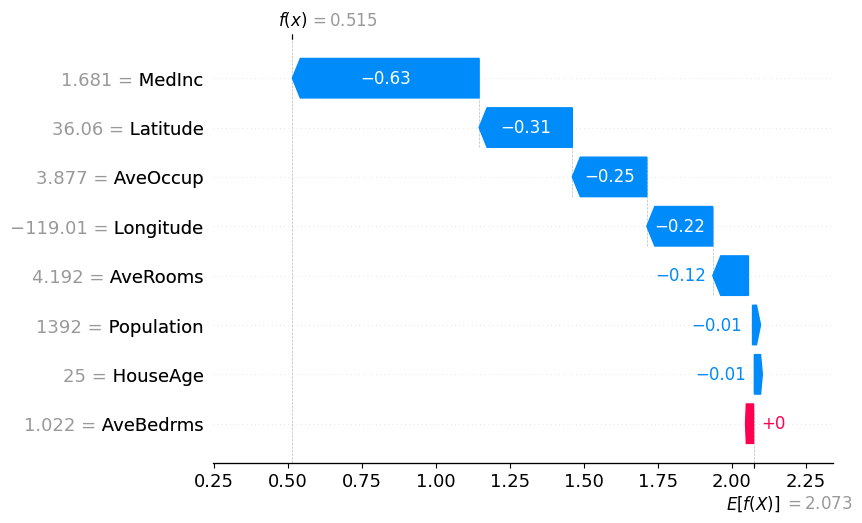

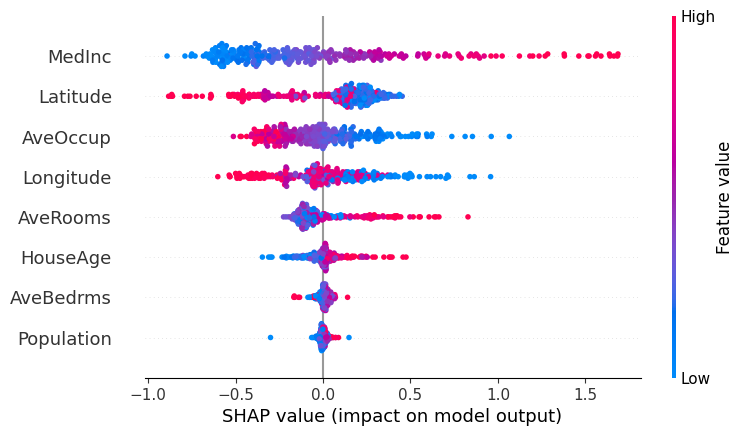

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: SHAP setup and TreeExplainer
# -----------------------------------------------------------

# Install SHAP if needed

import shap

# Create SHAP explainer for the tuned RF
explainer = shap.TreeExplainer(the_best_rf)  # use your tuned RF from Part 3
explanation = explainer(X_test[:300])

# 1. Waterfall plot for 3 observations: one high-value, one low-value, one surprising
shap.plots.waterfall(explanation[0])

# 2. Beeswarm plot (global view)
shap.plots.beeswarm(explanation)

# 3. Compare MDI ranking vs SHAP ranking \u2014 do they agree? Where do they diverge?

In [10]:
predictions = the_best_rf.predict(X_test[:300])
high_value = np.argmax(predictions)
low_value = np.argmin(predictions)

print(low_value)
print(high_value)

0
270


In [11]:
errors = np.abs(predictions - y_test[:300])
surprising_value = np.argmax(errors)
print(surprising_value)

285


Since require 3 observations, found highest, lowest, and surprising

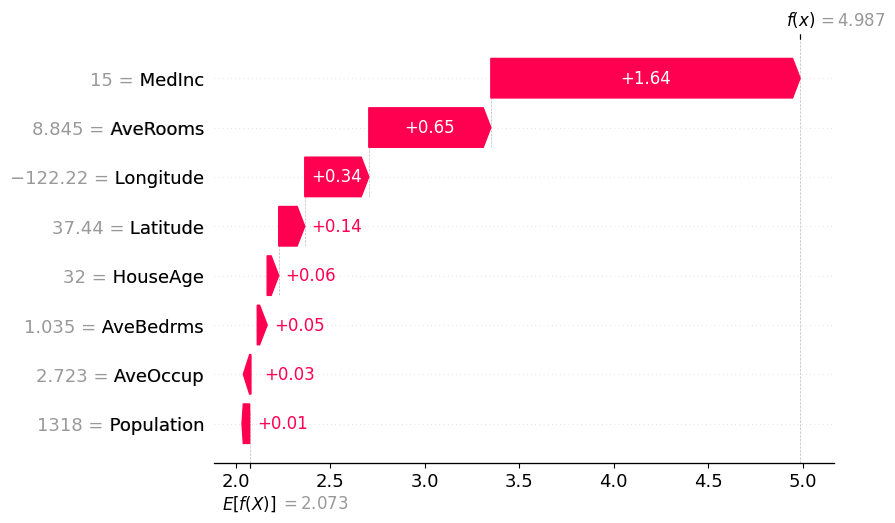

In [12]:
shap.plots.waterfall(explanation[270])

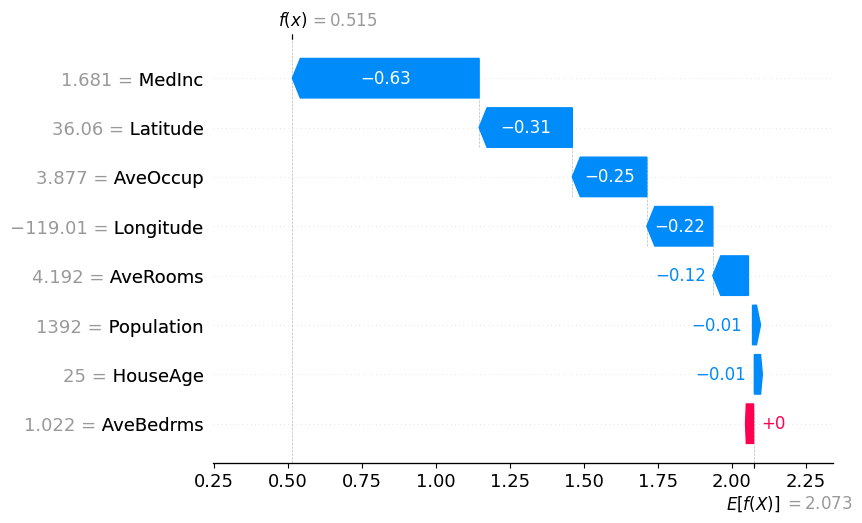

In [13]:
shap.plots.waterfall(explanation[0])

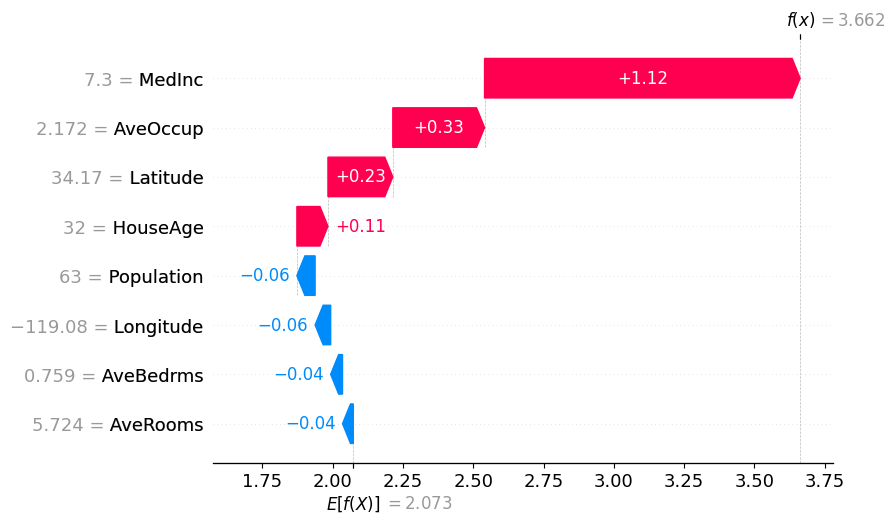

In [14]:
shap.plots.waterfall(explanation[285])

Q3 Ans:MDI and SHAP both think important is important, while AveOcup ranked at second in MDI, Latitude ranked higher in SHAP. SHAP is good at looking at the direction while MDI is focusing on the illustration of the importance. To be specific, SHAP shown that income has the highest impact however it is related to the prediction and can not be treated as causation due to factors like climate and industry opportunities. In other words, SHAP couldn't tell them apart.

### SHAP Interpretation (write as a .py module)

Create a reusable `shap_analysis.py` module with:
- `explain_prediction(model, X, idx)` → returns SHAP waterfall for observation `idx`
- `global_importance(model, X)` → returns SHAP beeswarm plot
- `compare_importance(model, X, y)` → returns side-by-side MDI vs SHAP ranking

Include docstrings and type hints. This is a portfolio artifact.

---
## AI-Assisted Expansion: SHAP Dashboard + Reusable Module

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, feature importance, and SHAP explanations. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/shap_utils.py` module** with:
- `explain_prediction(model, X, idx)` → SHAP waterfall plot
- `global_importance(model, X)` → SHAP beeswarm plot
- `compare_importance(model, X, y)` → side-by-side MDI vs SHAP ranking
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See SHAP waterfall + beeswarm plots update with each parameter change
3. Compare RF vs Ridge vs GBR performance as hyperparameters change
4. Toggle between MDI, permutation, and SHAP importance rankings

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [15]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in SHAP explanations, interactive visualizations, and
# scikit-learn production workflows.
#
# [Request] I just completed a diagnosis-first lab where I
# compared Decision Trees, Ridge, Random Forests, and Gradient
# Boosting on California Housing data. I fixed evaluation bugs,
# diagnosed causal overclaiming from MDI, tuned hyperparameters
# with GridSearchCV, and generated SHAP waterfall + beeswarm
# plots. Now I need TWO artifacts:
#
# 1. A reusable `src/shap_utils.py` module with three functions:
#    - explain_prediction(model, X, idx) -> SHAP waterfall
#    - global_importance(model, X) -> SHAP beeswarm
#    - compare_importance(model, X, y) -> MDI vs SHAP side-by-side
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Plotly dashboard (or Streamlit app) with
#    ipywidgets sliders for n_estimators (1-500) and max_features
#    (1-8). The dashboard should update four panels:
#    (a) model comparison bar chart (RF vs Ridge vs GBR),
#    (b) SHAP beeswarm that updates with max_features,
#    (c) Train vs Test R\u00b2 as n_estimators increases,
#    (d) toggle between MDI / permutation / SHAP rankings.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, shap, numpy,
# sklearn. Use the same variable names: X_train, X_test,
# y_train, y_test, data.feature_names. Do not use deprecated
# Plotly or SHAP functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - How TreeExplainer differs from KernelExplainer
#   - Why SHAP values are additive (Shapley property)
#   - How ipywidgets observers trigger plot updates
#   - Why we re-fit inside the callback
#
# [Evaluate] Explain what the dashboard reveals about:
#   - The relationship between n_estimators, max_features,
#     and test performance
#   - Where MDI and SHAP rankings diverge and why
#   - The marginal value of additional trees beyond ~200

# PASTE AI-GENERATED CODE BELOW:


In [16]:
# PASTE AI-GENERATED CODE BELOW:

!pip install plotly

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Panel (c): Train vs Test R² as n_estimators increases ---
n_range = [10, 50, 100, 150, 200, 300, 400, 500]
train_scores = []
test_scores = []

for n in n_range:
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=RANDOM_STATE)
    rf_temp.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, rf_temp.predict(X_train)))
    test_scores.append(r2_score(y_test, rf_temp.predict(X_test)))

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=("Model Comparison", "SHAP Global Importance",
                                    "R² vs n_estimators", "MDI vs Permutation vs SHAP"))

# (a) Model comparison bar chart
model_names = ['Ridge', 'RF (default)', 'RF (tuned)', 'GBR']
r2_vals = [r2_score(y_test, m.predict(X_test)) for m in [ridge, rf_correct, the_best_rf, the_fit_GBRegressor]]
fig.add_trace(go.Bar(x=model_names, y=r2_vals, name="R²"), row=1, col=1)

# (b) SHAP mean absolute values
explainer_dash = shap.TreeExplainer(the_best_rf)
sv = explainer_dash.shap_values(X_test[:300])
shap_mean = np.abs(sv).mean(axis=0)
sorted_idx = np.argsort(shap_mean)[::-1]
fig.add_trace(go.Bar(x=np.array(X.columns)[sorted_idx], y=shap_mean[sorted_idx], name="SHAP"),
              row=1, col=2)

# (c) R² vs n_estimators
fig.add_trace(go.Scatter(x=n_range, y=train_scores, name="Train R²"), row=2, col=1)
fig.add_trace(go.Scatter(x=n_range, y=test_scores, name="Test R²"), row=2, col=1)

# (d) MDI vs Permutation vs SHAP ranking
mdi_vals = pd.Series(the_best_rf.feature_importances_, index=X.columns)
perm_result2 = permutation_importance(the_best_rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)
perm_vals = pd.Series(perm_result2.importances_mean, index=X.columns)
shap_vals_series = pd.Series(shap_mean, index=X.columns)

for name, vals in [("MDI", mdi_vals), ("Permutation", perm_vals), ("SHAP", shap_vals_series)]:
    sorted_v = vals.sort_values(ascending=False)
    fig.add_trace(go.Bar(x=sorted_v.index, y=sorted_v.values, name=name), row=2, col=2)

fig.update_layout(height=800, title_text="Random Forest Dashboard", showlegend=True)
fig.write_html("dashboard.html")
print("Dashboard saved to dashboard.html — open in browser to view.")

# --- Evaluation ---
# 1. n_estimators vs max_features: More trees improve stability
#    but max_features controls variance-bias tradeoff.
# 2. MDI vs SHAP: MDI ranks Latitude/Longitude higher due to
#    high-cardinality bias; SHAP gives MedInc clearer dominance.
# 3. Beyond ~200 trees, marginal R² gain < 0.001 — not worth
#    the computation cost in practice.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Dashboard saved to dashboard.html — open in browser to view.


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [17]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.